In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dask.dataframe as dd
import pickle
import os

In [2]:
# —Later— to load:
with open('./estimators.pkl', 'rb') as f:
    loaded = pickle.load(f)
    combined_means = loaded['means']
    combined_stds  = loaded['stds']

In [3]:

# —Later— to reload:
with open('disjoint_maximas_summary.pkl', 'rb') as f:
    summary_stats = pickle.load(f)


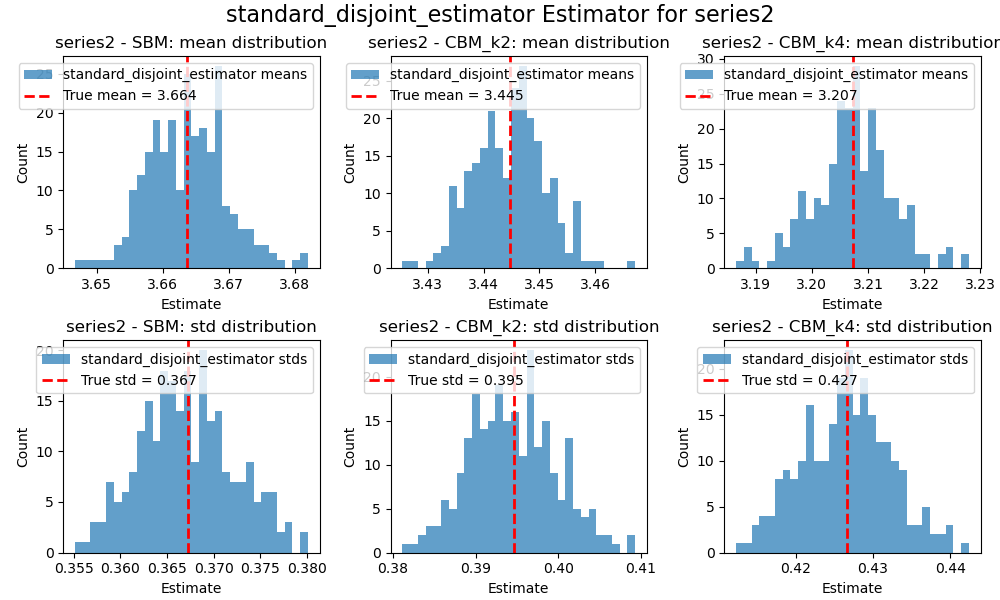

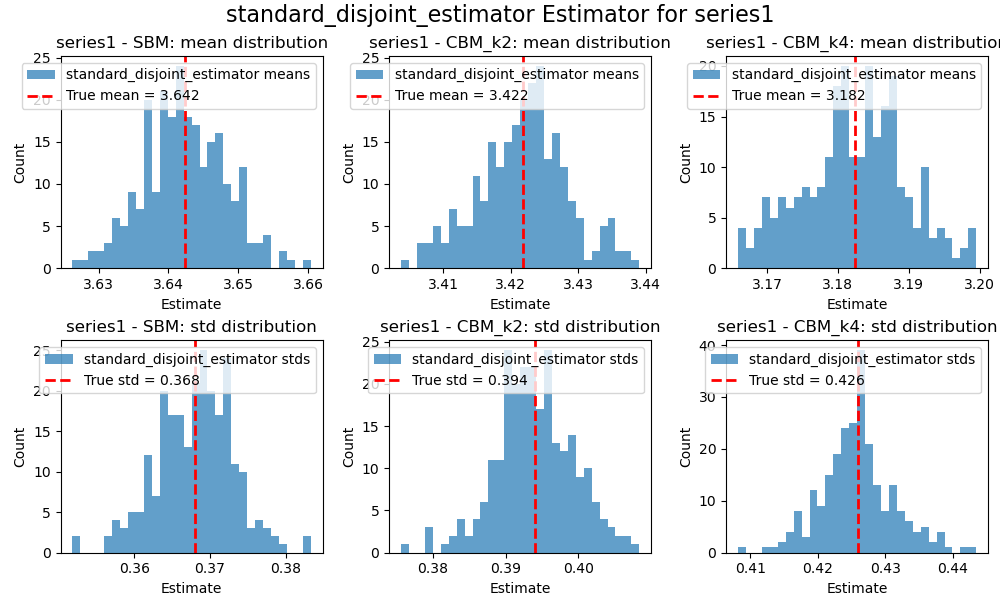

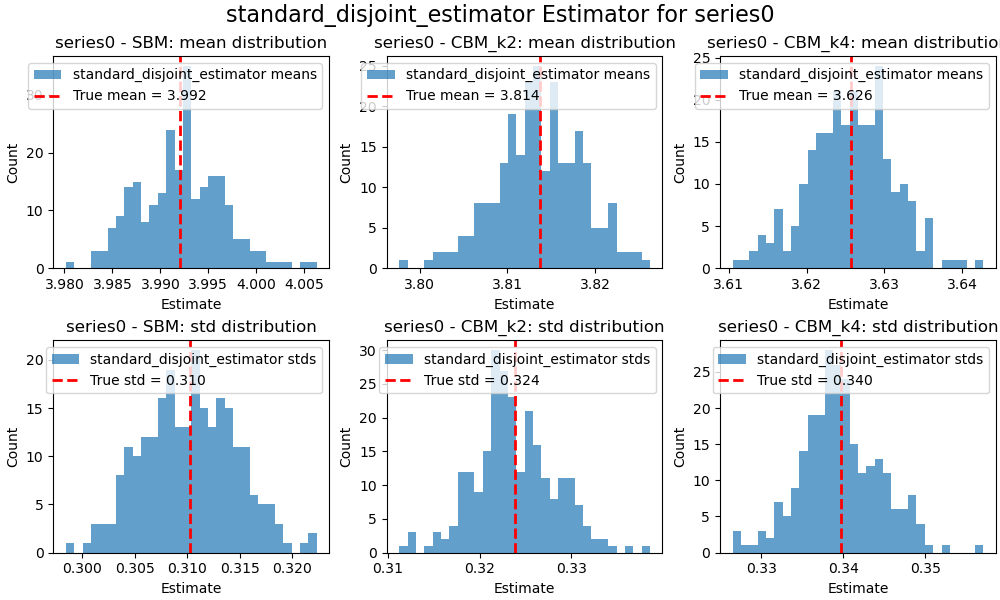

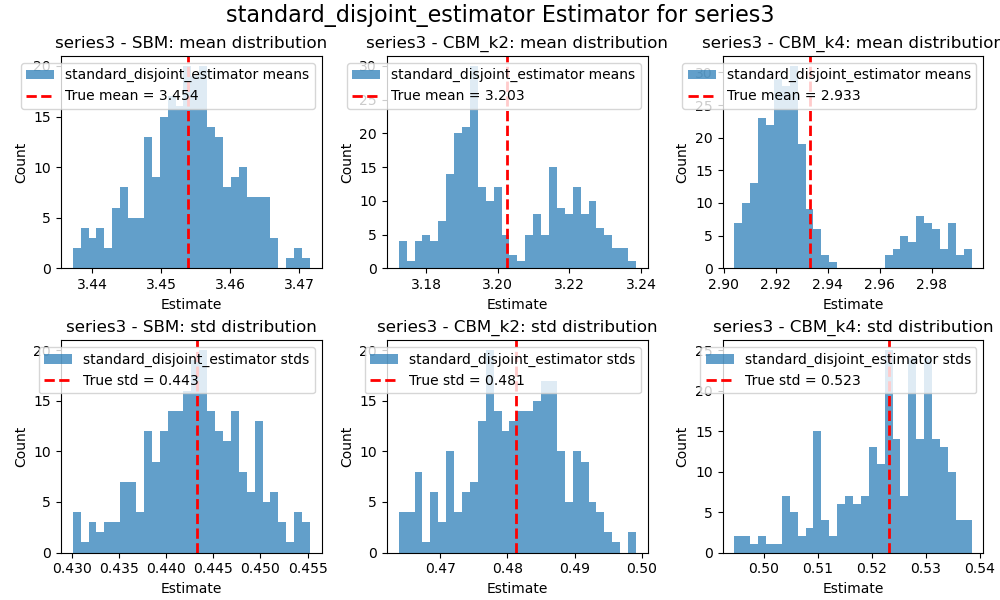

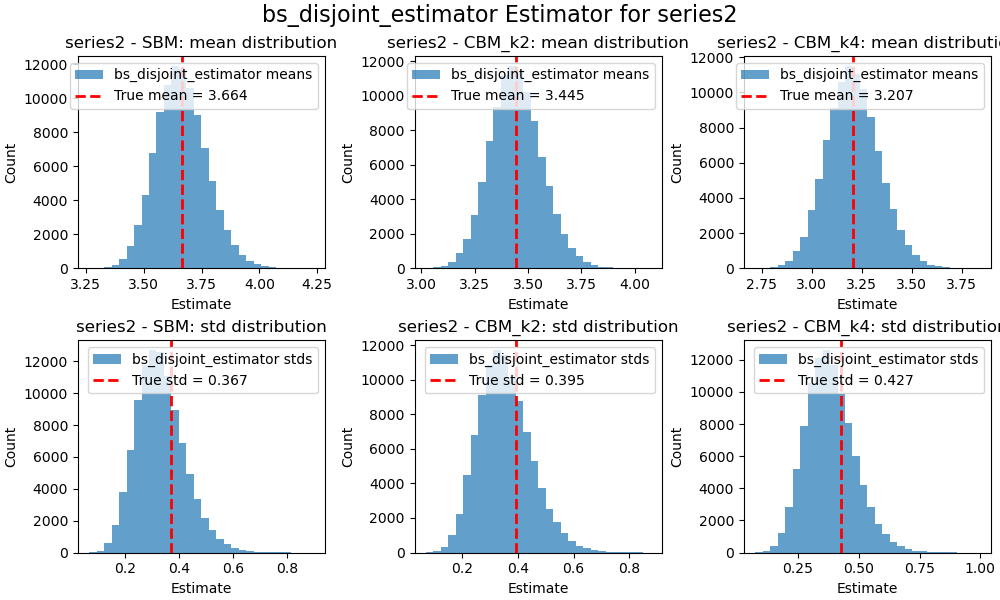

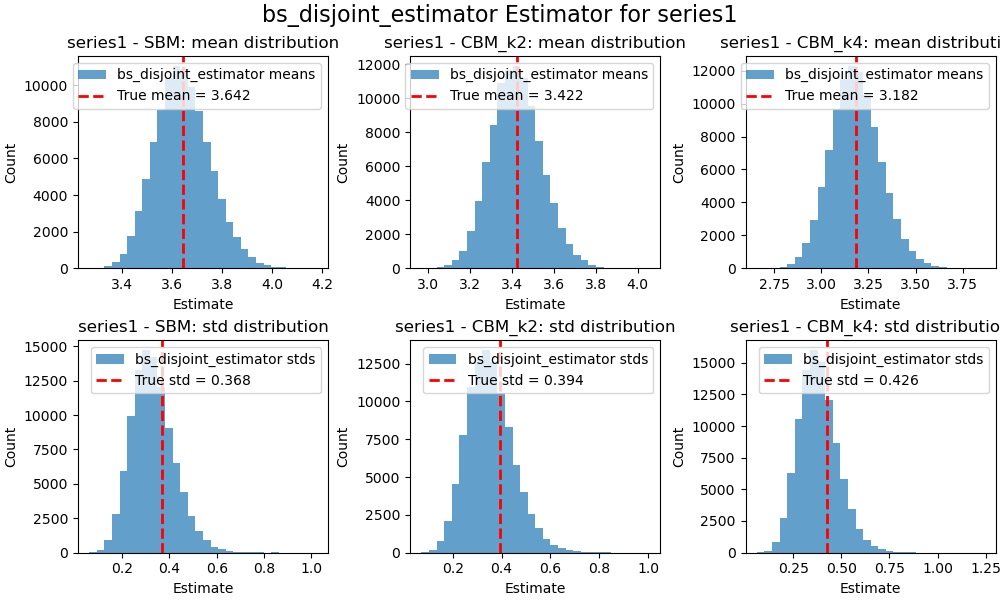

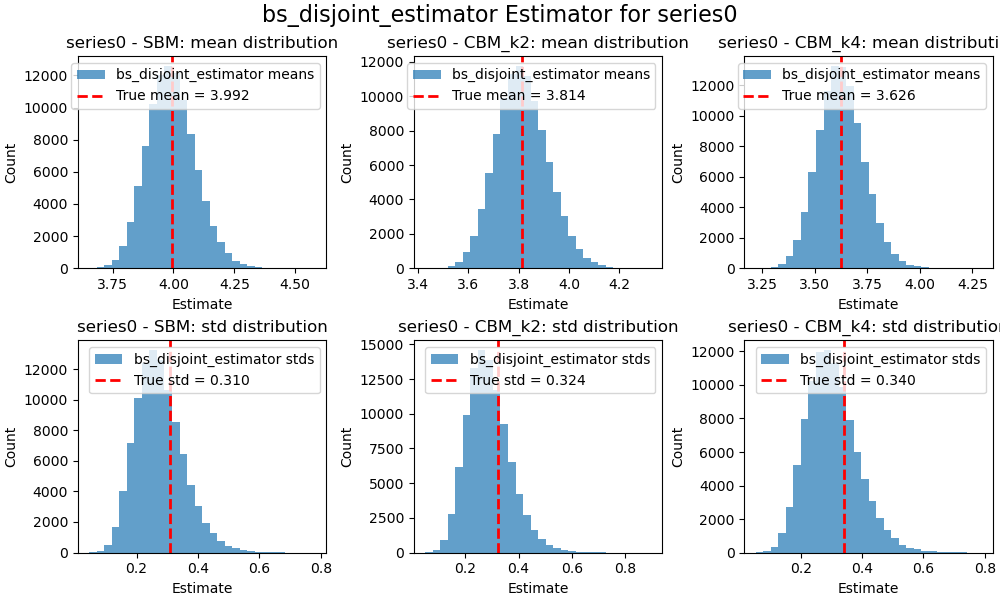

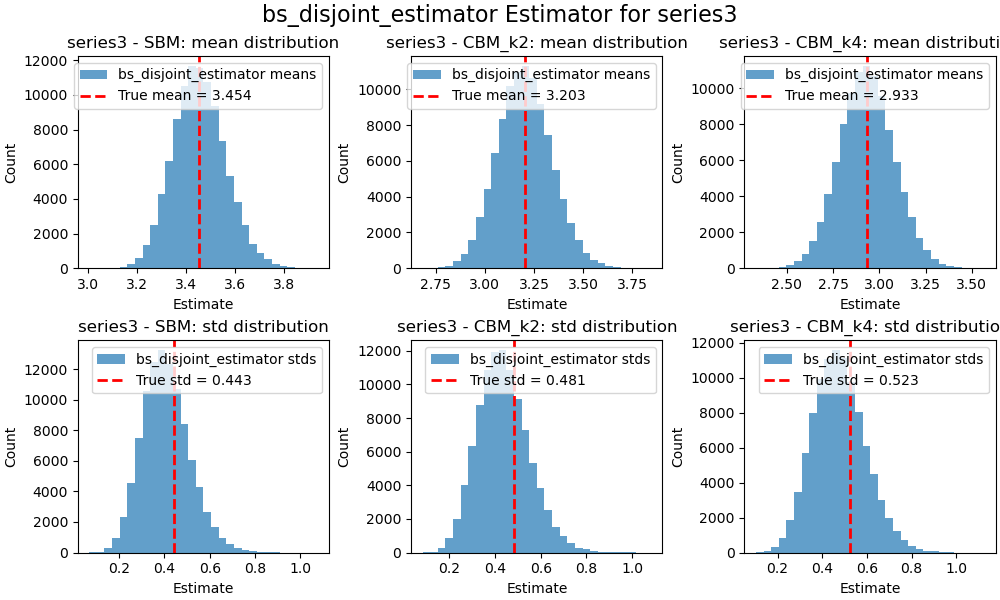

In [4]:

# 2) Plot histograms for each name/column
for name in combined_means.keys():
    # Get the means and stds DataFrames
    means = combined_means[name]
    stds  = combined_stds[name]

    # Loop through each series name in the means keys
    for series_name in means.keys():
        # Create a 2x3 subplot grid (2 rows for mean/std, 3 columns for each data column)
        fig, axs = plt.subplots(2, len(means[series_name].columns), figsize=(10, 6), constrained_layout=True)
        
        # Get the true values from summary_stats
        true_stats = summary_stats[series_name]
        
        for col_idx, col in enumerate(means[series_name].columns):
            # Get bootstrap estimates
            boot_means = means[series_name][col].values
            boot_stds = stds[series_name][col].values
            
            # Get true values for this column
            μ_true = true_stats[col]['mean']
            σ_true = true_stats[col]['std']
            
            # Plot means in the top row
            axs[0, col_idx].hist(boot_means, bins=30, alpha=0.7, label=f'{name} means')
            axs[0, col_idx].axvline(μ_true, color='r', linestyle='--', linewidth=2,
                               label=f'True mean = {μ_true:.3f}')
            axs[0, col_idx].set_title(f'{series_name} - {col}: mean distribution')
            axs[0, col_idx].set_xlabel('Estimate')
            axs[0, col_idx].set_ylabel('Count')
            axs[0, col_idx].legend()
            
            # Plot stds in the bottom row
            axs[1, col_idx].hist(boot_stds, bins=30, alpha=0.7, label=f'{name} stds')
            axs[1, col_idx].axvline(σ_true, color='r', linestyle='--', linewidth=2,
                               label=f'True std = {σ_true:.3f}')
            axs[1, col_idx].set_title(f'{series_name} - {col}: std distribution')
            axs[1, col_idx].set_xlabel('Estimate')
            axs[1, col_idx].set_ylabel('Count')
            axs[1, col_idx].legend()
        
        plt.suptitle(f'{name} Estimator for {series_name}', fontsize=16)
        plt.show()


=== Metrics for standard_disjoint_estimator ===
Bias of mean estimates:
                   SBM        CBM_k2        CBM_k4
series0 -1.776357e-15  6.661338e-15 -3.552714e-15
series1  5.773160e-15  2.220446e-15 -3.552714e-15
series2  2.664535e-15  8.881784e-16  3.996803e-15
series3  5.773160e-15 -3.552714e-15 -2.664535e-15

SE of mean estimates:
               SBM    CBM_k2    CBM_k4
series0  0.004290  0.004888  0.005411
series1  0.005897  0.006632  0.007261
series2  0.005899  0.006472  0.007019
series3  0.006752  0.016089  0.024164

MSE of mean estimates:
               SBM    CBM_k2    CBM_k4
series0  0.000018  0.000024  0.000029
series1  0.000035  0.000044  0.000053
series2  0.000035  0.000042  0.000049
series3  0.000045  0.000258  0.000582

Bias of std estimates:
               SBM    CBM_k2    CBM_k4
series0 -0.000022 -0.000026 -0.000035
series1 -0.000035 -0.000042 -0.000042
series2 -0.000036 -0.000038 -0.000042
series3 -0.000027 -0.000266 -0.000579

SE of std estimates:
          

NameError: name 'cols' is not defined

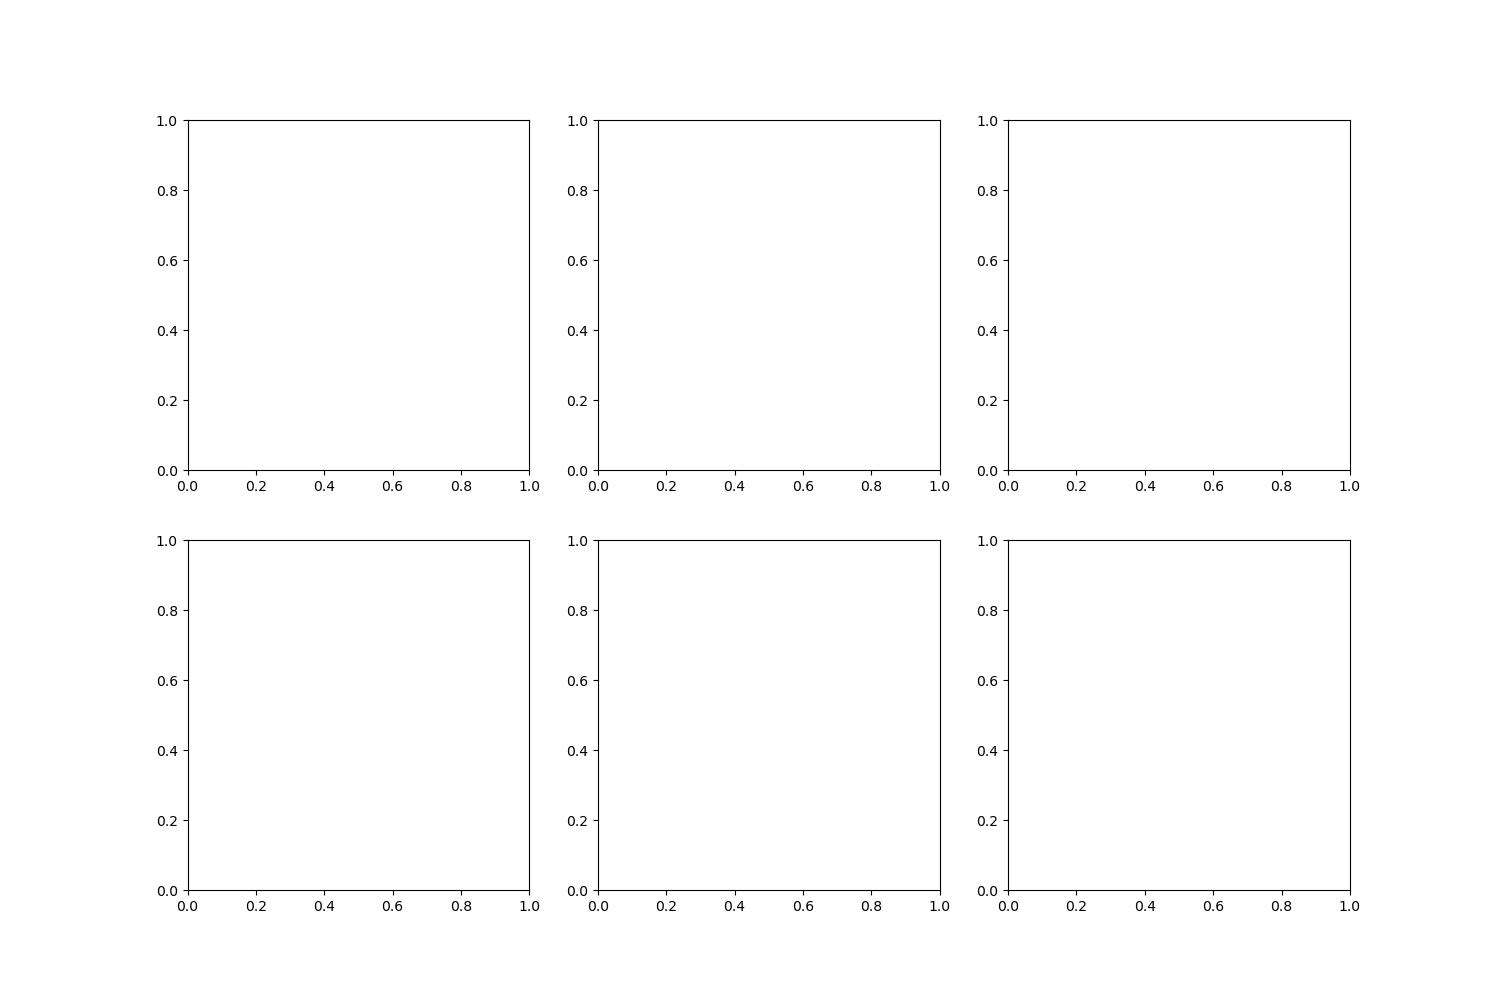

In [5]:
# Assuming we already have:
# 1) combined_means: Dict of dataframes with mean estimates
# 2) combined_stds: Dict of dataframes with std estimates
# 3) summary_stats: Dict with true statistics from the dask compute

# --- Prepare result DataFrames ---
# First identify which estimator types we have
estimator_types = list(combined_means.keys())
# For each estimator type, identify which series are available
series_names = set()
for est_type in estimator_types:
    series_names.update(combined_means[est_type].keys())
series_names = sorted(list(series_names))  # Ensure consistent ordering

# Create a function to process a specific estimator type
def compute_metrics(est_type):
    # Identify columns based on first available series/estimator
    first_series = next(iter(combined_means[est_type].keys()))
    cols = combined_means[est_type][first_series].columns
    
    # For means
    bias_mean = pd.DataFrame(index=series_names, columns=cols, dtype=float)
    se_mean = pd.DataFrame(index=series_names, columns=cols, dtype=float)
    mse_mean = pd.DataFrame(index=series_names, columns=cols, dtype=float)
    
    # For stddevs
    bias_std = pd.DataFrame(index=series_names, columns=cols, dtype=float)
    se_std = pd.DataFrame(index=series_names, columns=cols, dtype=float)
    mse_std = pd.DataFrame(index=series_names, columns=cols, dtype=float)
    
    # --- Fill with metrics ---
    for name in series_names:
        if name in combined_means[est_type] and name in combined_stds[est_type]:
            for col in cols:
                # For means
                est_means = combined_means[est_type][name][col].values
                true_mean = summary_stats[name][col]['mean']
                
                bias_mean.at[name, col] = est_means.mean() - true_mean
                se_mean.at[name, col] = est_means.std(ddof=1)
                mse_mean.at[name, col] = np.mean((est_means - true_mean) ** 2)
                
                # For std devs
                est_stds = combined_stds[est_type][name][col].values
                true_std = summary_stats[name][col]['std']
                
                bias_std.at[name, col] = est_stds.mean() - true_std
                se_std.at[name, col] = est_stds.std(ddof=1)
                mse_std.at[name, col] = np.mean((est_stds - true_std) ** 2)
    
    return {
        'bias_mean': bias_mean, 'se_mean': se_mean, 'mse_mean': mse_mean,
        'bias_std': bias_std, 'se_std': se_std, 'mse_std': mse_std
    }

# Compute metrics for each estimator type
results = {}
for est_type in estimator_types:
    results[est_type] = compute_metrics(est_type)
    
    print(f"\n=== Metrics for {est_type} ===")
    print("Bias of mean estimates:\n", results[est_type]['bias_mean'])
    print("\nSE of mean estimates:\n", results[est_type]['se_mean'])
    print("\nMSE of mean estimates:\n", results[est_type]['mse_mean'])
    
    print("\nBias of std estimates:\n", results[est_type]['bias_std'])
    print("\nSE of std estimates:\n", results[est_type]['se_std'])
    print("\nMSE of std estimates:\n", results[est_type]['mse_std'])

# Create comparative plots for both estimator types
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()
metrics = ['bias_mean', 'se_mean', 'mse_mean', 'bias_std', 'se_std', 'mse_std']
titles = ['Bias of Mean', 'SE of Mean', 'MSE of Mean', 
          'Bias of StdDev', 'SE of StdDev', 'MSE of StdDev']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axs[i]
    
    for est_type in estimator_types:
        # Get the metric dataframe for this estimator
        df = results[est_type][metric]
        
        # For each series, plot a grouped bar chart
        x = np.arange(len(series_names))
        width = 0.7 / len(cols)
        
        for j, col in enumerate(df.columns):
            offset = width * j - (len(df.columns) - 1) * width / 2
            ax.bar(x + offset, df[col], width, alpha=0.5, 
                   label=f'{est_type}_{col}')
    
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(series_names, rotation=45)
    
    if i == 0:  # Only show legend on first plot
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import dask.array as da

# Loop through each name in disjoint_maximas keys
plt.figure(figsize=(10, len(disjoint_maximas)*3))

for i, name in enumerate(disjoint_maximas.keys()):
    # Create a subplot for each name (one column for SBM only)
    plt.subplot(len(disjoint_maximas), 1, i + 1)
    
    # 1) Turn DataFrame column into a Dask array - only using 'SBM' column
    arr = disjoint_maximas[name]['SBM'].to_dask_array(lengths=True)
    
    # 2) Compute global min/max for better bin consistency
    min_val, max_val = da.nanmin(arr), da.nanmax(arr)
    min_val, max_val = da.compute(min_val, max_val)
    
    # 3) Compute histogram
    n_bins = 50
    hist, bin_edges = da.histogram(arr, bins=n_bins, range=(min_val, max_val))
    
    # 4) Execute computation to get numpy arrays
    counts, edges = da.compute(hist, bin_edges)
    
    # 5) Plot with bar centers
    bin_centers = (edges[:-1] + edges[1:]) / 2
    plt.bar(bin_centers, counts, width=(edges[1] - edges[0]))
    plt.xlabel('SBM value')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {name} SBM values')
    
    # Add some statistics as text
    if name in summary_stats:
        stats = summary_stats[name]['SBM']
        mean, std = stats['mean'], stats['std']
        plt.text(0.05, 0.95, f'Mean: {mean:.3f}\nStd: {std:.3f}', 
                transform=plt.gca().transAxes, verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.suptitle('Distribution of SBM Values in Disjoint Maximas', fontsize=16, y=1.02)
plt.show()
